#### **Exploratory Data Analysis of Walmart Sales Data**

Here I have sourced the dataset from a Walmart competition to conduct Exploratory Data Analysis on it and develop Machine Learning Model.

In [76]:
# importing required dependencies

import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import plotly.graph_objects as go
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
from pmdarima.utils import decomposed_plot as p
from pmdarima.arima import decompose as d
le = LabelEncoder()

In [77]:
for category in [RuntimeWarning, FutureWarning, UserWarning]: 
    warnings.filterwarnings('ignore', category=category)

In [78]:
# Set up plotting parameters for better visualization
sns.set_theme(style='whitegrid')  # Adjust style as needed
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

# Enable all plots to be displayed in the notebook
%matplotlib inline

# Set Plotly template for consistent styling
px.defaults.template = "plotly_white"

In [79]:
# loading all required csv files
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

In [80]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [81]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [82]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [83]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [84]:
# Did inner joins on the above tables based on Store, Date, IsHoliday
df = train.merge(stores, on='Store', how='inner').merge(features, on=['Store', 'Date', 'IsHoliday'], how='inner')
df.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [85]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'],
      dtype='object')

In [86]:
# filling null values in MarkDown columns with 0
df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] = df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].fillna(0)

In [87]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106


In [88]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'],
      dtype='object')

In [89]:
df.info()
memory_in_bytes = df.memory_usage(deep=True).sum()
memory_in_mb = memory_in_bytes / (1024 ** 2)
print(f"Actual Memory usage: {memory_in_mb:.2f} MB")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     421570 non-null  float64
 10  MarkDown2     421570 non-null  float64
 11  MarkDown3     421570 non-null  float64
 12  MarkDown4     421570 non-null  float64
 13  MarkDown5     421570 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB
Actual Memory usage: 86.

In [90]:
df.isna().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
dtype: int64

In [91]:
# Encoding categorical variables
df['Type'] = le.fit_transform(df['Type'])
df['IsHoliday'] = le.fit_transform(df['IsHoliday'])
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,0,0,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,1,2010-02-12,46039.49,1,0,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106
2,1,1,2010-02-19,41595.55,0,0,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106
3,1,1,2010-02-26,19403.54,0,0,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106
4,1,1,2010-03-05,21827.90,0,0,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106


In [92]:
# Setting multi-index on Type, Store and Dept
df['Type'] = df['Type'].astype(int)
df['Store'] = df['Store'].astype(int)
df['Dept'] = df['Dept'].astype(int)
df.set_index(['Type','Store','Dept'], inplace=True)
df.head()

Date  Weekly_Sales  IsHoliday    Size  Temperature  \
Type Store Dept                                                             
0    1     1     2010-02-05      24924.50          0  151315        42.31   
           1     2010-02-12      46039.49          1  151315        38.51   
           1     2010-02-19      41595.55          0  151315        39.93   
           1     2010-02-26      19403.54          0  151315        46.63   
           1     2010-03-05      21827.90          0  151315        46.50   

                 Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  \
Type Store Dept                                                           
0    1     1          2.572        0.0        0.0        0.0        0.0   
           1          2.548        0.0        0.0        0.0        0.0   
           1          2.514        0.0        0.0        0.0        0.0   
           1          2.561        0.0        0.0        0.0        0.0   
           1          2.625        0.0        0.0        0.0        0.0   

                 MarkDown5         CPI  Unemployment  
Type Store Dept                                       
0    1     1           0.0  211.096358         8.106  
           1           0.0  211.242170         8.106  
           1           0.0  211.289143         8.106  
           1           0.0  211.319643         8.106  
           1           0.0  211.350143         8.106

In [93]:
# Accessing data for Type 0, Store 1, Dept 1. Testing the indexing
df.loc[(0,1,1)]

/var/folders/jx/3lsd8xl903n41xqm_6d7chtr0000gn/T/ipykernel_24493/4153213283.py:2: PerformanceWarning:

indexing past lexsort depth may impact performance.



Date  Weekly_Sales  IsHoliday    Size  Temperature  \
Type Store Dept                                                             
0    1     1     2010-02-05      24924.50          0  151315        42.31   
           1     2010-02-12      46039.49          1  151315        38.51   
           1     2010-02-19      41595.55          0  151315        39.93   
           1     2010-02-26      19403.54          0  151315        46.63   
           1     2010-03-05      21827.90          0  151315        46.50   
...                     ...           ...        ...     ...          ...   
           1     2012-09-28      18947.81          0  151315        76.08   
           1     2012-10-05      21904.47          0  151315        68.55   
           1     2012-10-12      22764.01          0  151315        62.99   
           1     2012-10-19      24185.27          0  151315        67.97   
           1     2012-10-26      27390.81          0  151315        69.16   

                 Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  \
Type Store Dept                                                           
0    1     1          2.572       0.00       0.00       0.00       0.00   
           1          2.548       0.00       0.00       0.00       0.00   
           1          2.514       0.00       0.00       0.00       0.00   
           1          2.561       0.00       0.00       0.00       0.00   
           1          2.625       0.00       0.00       0.00       0.00   
...                     ...        ...        ...        ...        ...   
           1          3.666    3666.27       7.64       1.65    1417.96   
           1          3.617    8077.89       0.00      18.22    3617.43   
           1          3.601    2086.18       0.00       8.11     602.36   
           1          3.594     950.33       0.00       4.93      80.25   
           1          3.506    2585.85      31.75       6.00    1057.16   

                 MarkDown5         CPI  Unemployment  
Type Store Dept                                       
0    1     1          0.00  211.096358         8.106  
           1          0.00  211.242170         8.106  
           1          0.00  211.289143         8.106  
           1          0.00  211.319643         8.106  
           1          0.00  211.350143         8.106  
...                    ...         ...           ...  
           1       4744.28  222.981658         6.908  
           1       3626.14  223.181477         6.573  
           1       5926.45  223.381296         6.573  
           1       2312.85  223.425723         6.573  
           1       1305.01  223.444251         6.573  

[143 rows x 13 columns]

In [94]:
# convert 'Date' to datetime (in-place)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

min_date = df['Date'].min()
max_date = df['Date'].max()

if pd.isna(min_date) or pd.isna(max_date):
	print("Date column contains no valid dates after conversion.")
else:
	print("Min date:", min_date.strftime('%Y-%m-%d'))
	print("Max date:", max_date.strftime('%Y-%m-%d'))
	date_range = max_date - min_date
	print(f"Range: {date_range.days} days")
	print(f"Years: {date_range.days/365:.2f}")

Min date: 2010-02-05
Max date: 2012-10-26
Range: 994 days
Years: 2.72


In [95]:
def summarize_dataframe(df):
    summary = {
        'mean': df.mean(),
        'median': df.median(),
        'mode': df.mode().iloc[0],  # mode() returns a DataFrame, take the first row
    }
    result = pd.DataFrame(summary)
    result.index.name = 'Feature'
    return result

summary_table = summarize_dataframe(df)
summary_table

,mean,median,mode
Feature,,,
Date,2011-06-18 08:30:31.963375104,2011-06-17 00:00:00,2011-12-23 00:00:00
Weekly_Sales,15981.258123,7612.03,10.0
IsHoliday,0.070358,0.0,0
Size,136727.915739,140167.0,39690
Temperature,60.090059,62.09,50.43
Fuel_Price,3.361027,3.452,3.638
MarkDown1,2590.074819,0.0,0.0
MarkDown2,879.974298,0.0,0.0
MarkDown3,468.087665,0.0,0.0


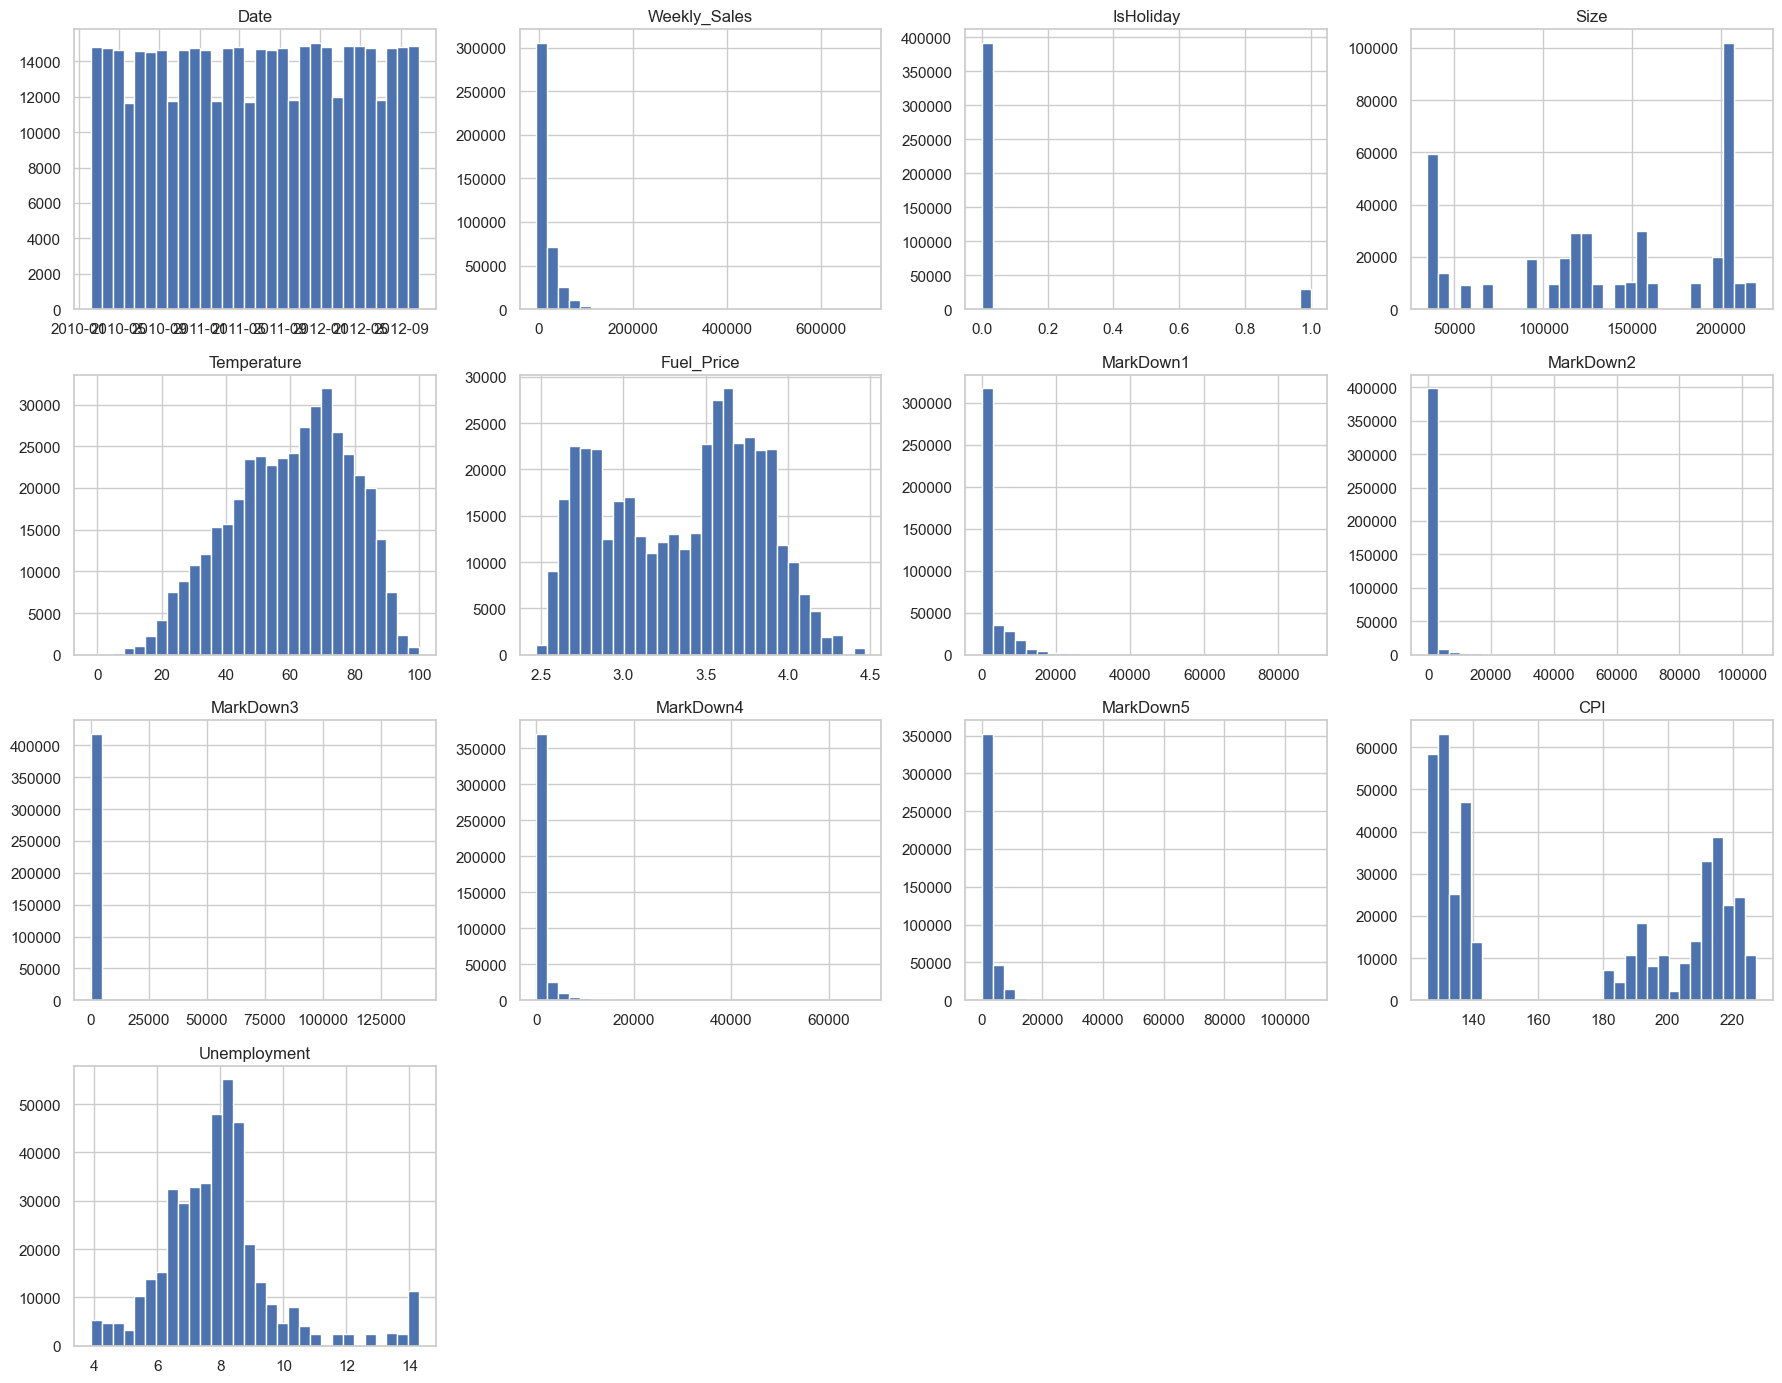

In [96]:
df.hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

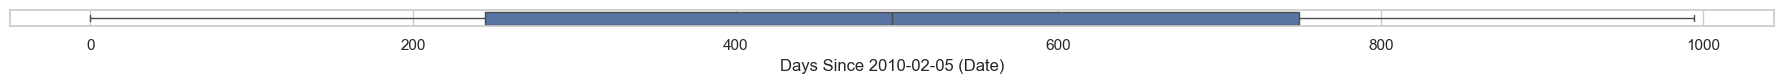

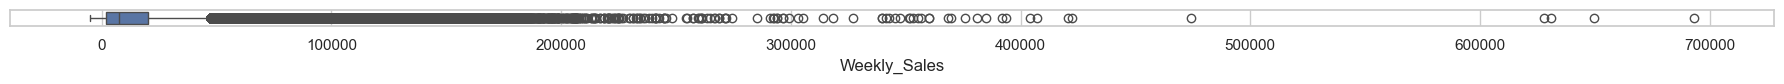

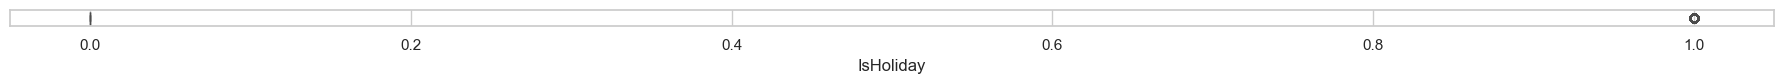

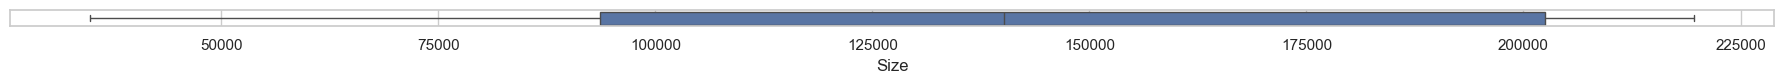

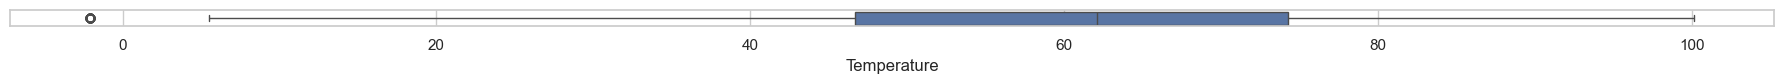

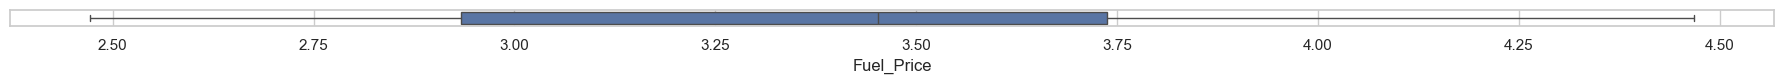

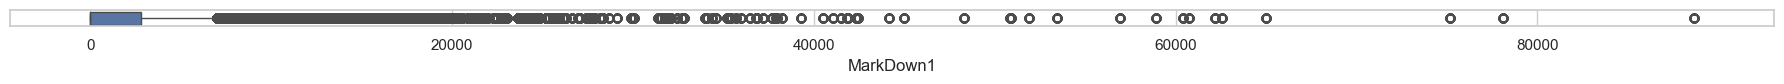

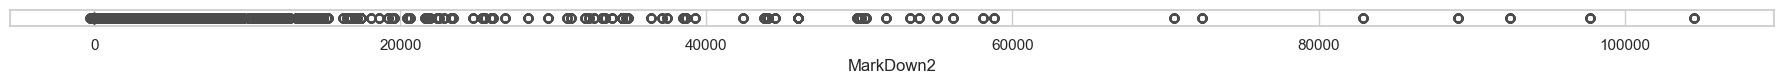

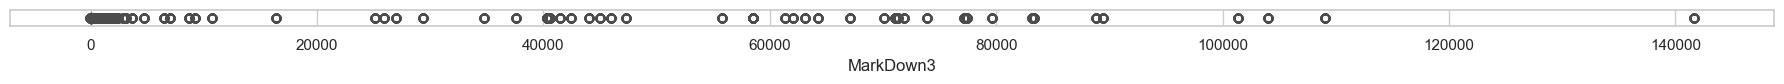

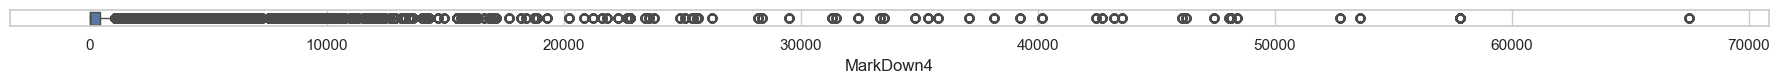

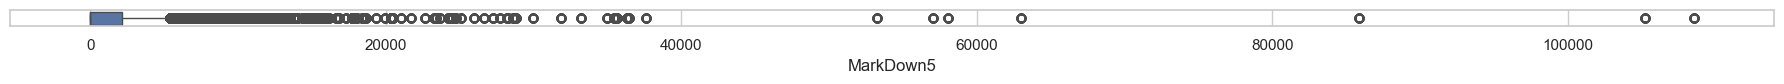

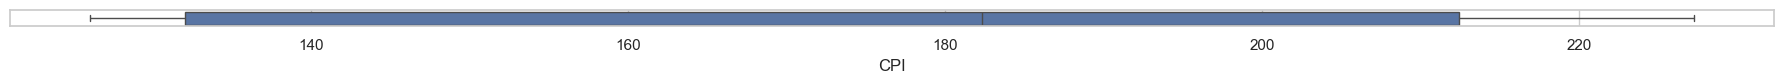

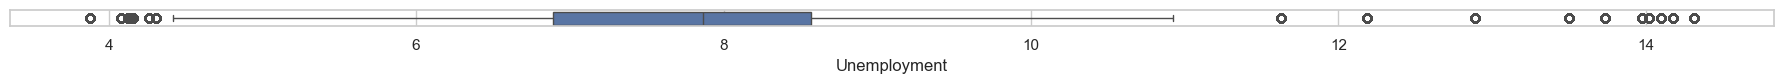

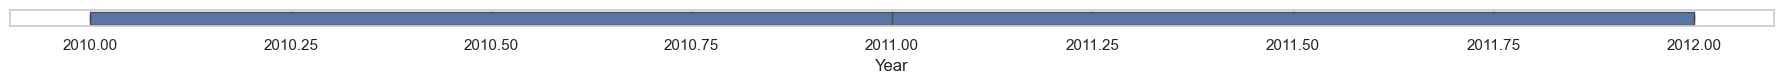

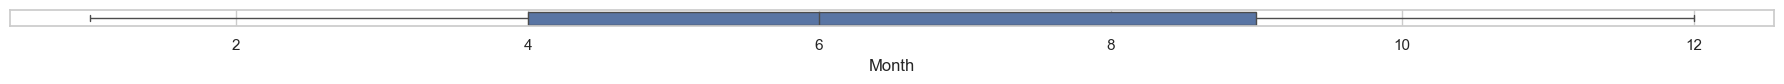

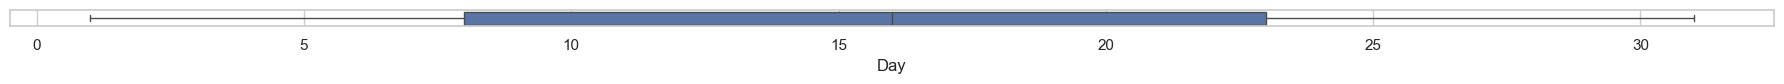

In [110]:
for i in df.columns:
    plt.figure(figsize=(18, 1))
    if df[i].dtype == 'datetime64[ns]':
        earliest_date = df[i].min()
        data_to_plot = (df[i] - earliest_date).dt.days
        xlabel = f'Days Since {earliest_date.date()} ({i})'
    else:
        data_to_plot = df[i]
        xlabel = i
    
    try:
        sns.boxplot(x=data_to_plot, orient='h')
        plt.xlabel(xlabel)
        plt.tight_layout()
        plt.show()
    except:
        print(f"Skipping column '{i}' due to plotting error.")

In [98]:
print(df.shape)
memory_in_bytes = df.memory_usage(deep=True).sum()
memory_in_mb = memory_in_bytes / (1024 ** 2)
print(f"Memory usage: {memory_in_mb:.2f} MB")

(421570, 13)
Memory usage: 59.15 MB


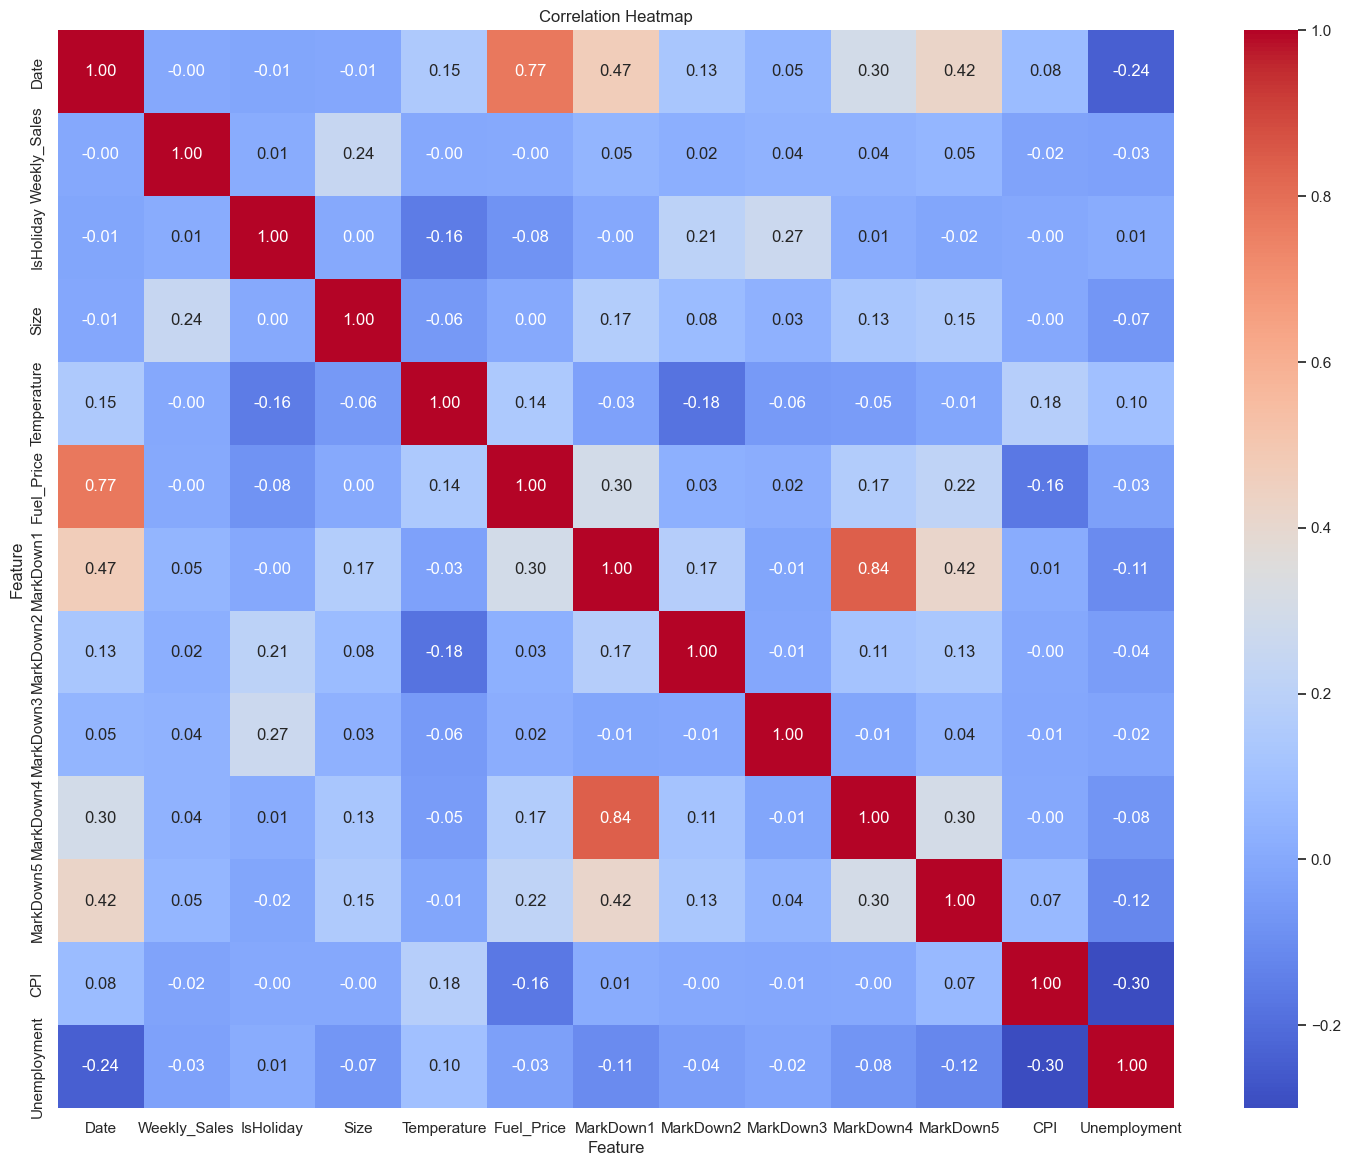

In [99]:
# Correlation heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [100]:
# break the date into separate columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [101]:
print(df.shape)
memory_in_bytes = df.memory_usage(deep=True).sum()
memory_in_mb = memory_in_bytes / (1024 ** 2)
print(f"Memory usage: {memory_in_mb:.2f} MB")

(421570, 16)
Memory usage: 63.97 MB


In [ ]:
# Use a reset index copy so 'Type', 'Store', 'Dept' are available as columns to statsmodels
df_reset = df.reset_index()

# build formula from df_reset.columns, excluding the target and any datetime columns
exclude = ['Weekly_Sales'] + [col for col in df_reset.columns if pd.api.types.is_datetime64_any_dtype(df_reset[col])]
rhs_cols = [c for c in df_reset.columns if c not in exclude and c != 'Type']  # we'll add Type as categorical explicitly

# construct formula and include Type as categorical only if present
full = "Weekly_Sales ~ " + " + ".join(rhs_cols)
if 'Type' in df_reset.columns:
	full += " + C(Type)"
print("Formula:", full)

# fit the model on the reset dataframe (so Type is defined)
add_model_full = smf.ols(full, data=df_reset).fit()
print(add_model_full.summary())

Formula: Weekly_Sales ~ Store + Dept + IsHoliday + Size + Temperature + Fuel_Price + MarkDown1 + MarkDown2 + MarkDown3 + MarkDown4 + MarkDown5 + CPI + Unemployment + Year + Month + Day + C(Type)
                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     2334.
Date:                Thu, 11 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:37:35   Log-Likelihood:            -4.8068e+06
No. Observations:              421570   AIC:                         9.614e+06
Df Residuals:                  421551   BIC:                         9.614e+06
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
               

In [103]:
# avg sales on workday vs holiday
diff = df.groupby('IsHoliday')['Weekly_Sales'].mean()
print(diff)
print("Differnce is :",(diff.iloc[1]-diff.iloc[0])/diff.iloc[1])

IsHoliday
0    15901.445069
1    17035.823187
Name: Weekly_Sales, dtype: float64
Differnce is : 0.06658780769598129


In [104]:
# -------------------------------
# VIF calculation
# -------------------------------
# Get design matrix (X) from the fitted model
X = add_model_full.model.exog
feature_names = add_model_full.model.exog_names
# Compute VIF for each explanatory variable
vif_data = pd.DataFrame()
vif_data["Variable"] = feature_names
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

# Drop intercept row
vif_data = vif_data[vif_data["Variable"] != "Intercept"].reset_index(drop=True)

print(vif_data)

        Variable       VIF
0   C(Type)[T.1]  2.480021
1   C(Type)[T.2]  2.753239
2          Store  1.395658
3           Dept  1.001557
4      IsHoliday  1.180754
5           Size  3.154810
6    Temperature  1.317181
7     Fuel_Price  3.544065
8      MarkDown1  4.513377
9      MarkDown2  1.142231
10     MarkDown3  1.104644
11     MarkDown4  3.573119
12     MarkDown5  1.395966
13           CPI  1.363828
14  Unemployment  1.309396
15          Year  4.823462
16         Month  1.267690
17           Day  1.042324


In [ ]:
#randomforest model with y as 'Weekly_Sales' and x as all other columns
X = df.drop(columns=['Weekly_Sales','Date'])
y = df['Weekly_Sales']
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
feature_importances = pd.DataFrame(importances, index=X.columns, columns=['importance']).sort_values(by='importance', ascending=False)
print(feature_importances)

"X = df.drop(columns=['Weekly_Sales','Date'])\ny = df['Weekly_Sales']\nrf = RandomForestRegressor(n_estimators=100, random_state=42)\nrf.fit(X, y)\nimportances = rf.feature_importances_\nfeature_importances = pd.DataFrame(importances, index=X.columns, columns=['importance']).sort_values(by='importance', ascending=False)\nprint(feature_importances)"

In [106]:
# Aggregate weekly sales per (Type, Store, Dept) and plot
ts_combo = df_reset.groupby(['Type', 'Store', 'Dept', 'Date'])['Weekly_Sales'].sum().reset_index()
ts_combo['combo'] = 'T' + ts_combo['Type'].astype(str) + '_S' + ts_combo['Store'].astype(str) + '_D' + ts_combo['Dept'].astype(str)

# To avoid overcrowding, plot the top N combos by total sales (adjust top_n if needed)
top_n = 30
top_combos = ts_combo.groupby('combo')['Weekly_Sales'].sum().nlargest(top_n).index.tolist()

fig = px.line(
    ts_combo[ts_combo['combo'].isin(top_combos)],
    x='Date',
    y='Weekly_Sales',
    color='combo',
    title=f'Weekly Sales for Top {top_n} Type-Store-Dept Combinations'
)
fig.update_xaxes(title='Date')
fig.update_yaxes(title='Weekly Sales')
fig.show()

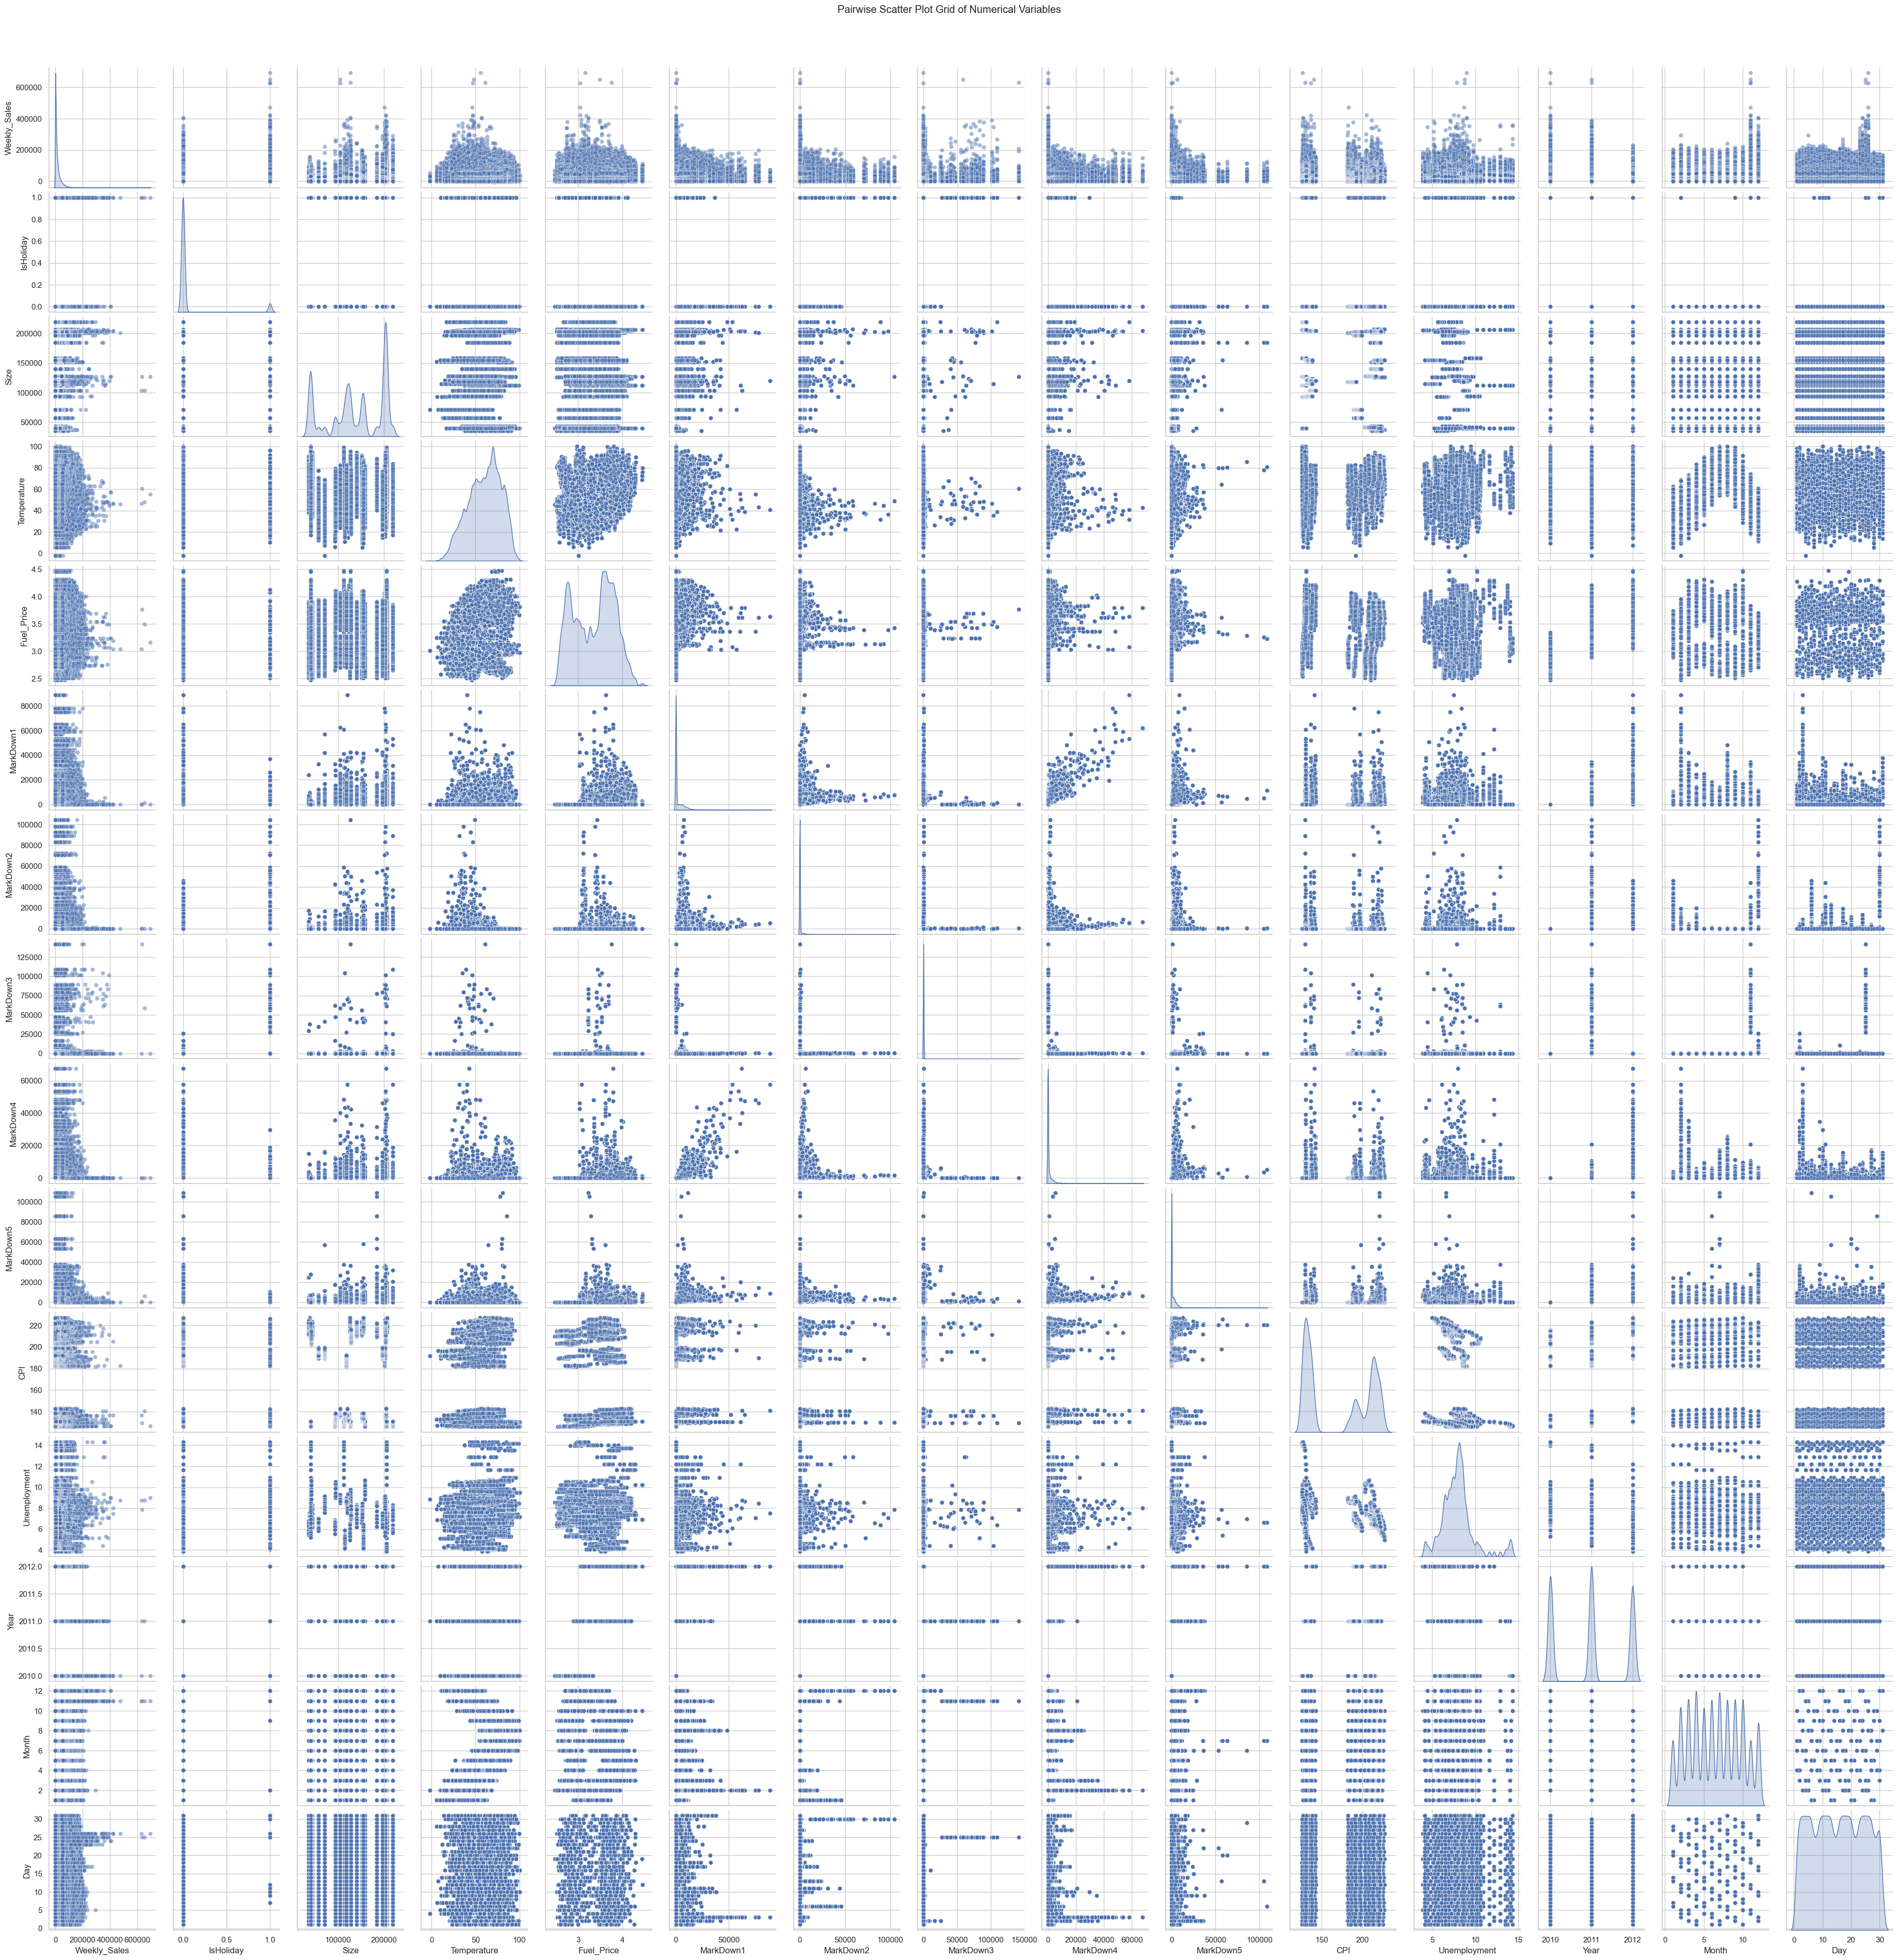

In [107]:
# Create the pairplot (grid of scatter plots)
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5})  # 'kde' on diagonal for density plots; alpha for transparency in scatters

# Customize the plot (optional)
plt.suptitle('Pairwise Scatter Plot Grid of Numerical Variables', y=1.02)  # Add a title
plt.show()

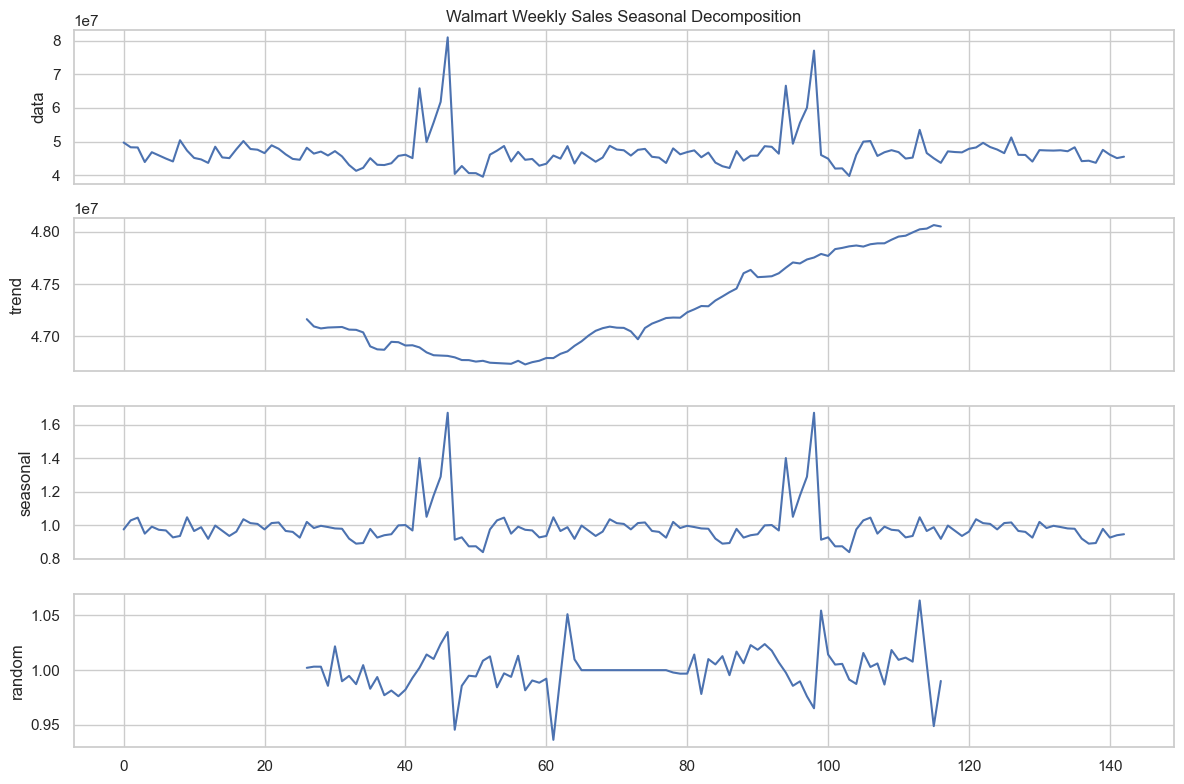

In [108]:
# Define figure kwargs (was missing)
figure_kwargs = {'figsize': (12, 8)}

# Aggregate Weekly_Sales by Date to create a single time series (sum across stores/depts)
ts_data = df.groupby('Date')['Weekly_Sales'].sum()

# Ensure Date is datetime and set as index
ts_data.index = pd.to_datetime(ts_data.index)
ts_data = ts_data.sort_index()  # Ensure sorted

# Decompose into trend, seasonal, and residual (multiplicative model; period=52 for weekly data)
decomposed = d(ts_data.values, 'multiplicative', m=52)

# Plot the decomposed signal as subplots
axes = p(decomposed, figure_kwargs=figure_kwargs, show=False)
axes[0].set_title("Walmart Weekly Sales Seasonal Decomposition")
plt.tight_layout()
plt.show()